# RAG — Retrieval Augmented Generation (Part 1)

### Build a complete RAG pipeline from scratch

---

This notebook is the **hands-on companion** to **Section 4 (Part 1)** on the course page.

We'll build a RAG system step by step over TechStore's internal documents:
- `return_policy.txt` — customer-facing return policy
- `employee_handbook.txt` — HR policies (PTO, remote work, benefits)
- `product_catalog.txt` — product descriptions and specs

**By the end:** You'll have a working Q&A system that answers questions from these documents accurately — no hallucination, no guessing.

**Tools used:** OpenAI (embeddings + generation), ChromaDB (vector database), LangChain (text splitting)

---

## Setup

In [ ]:
!pip install openai chromadb python-dotenv tiktoken langchain -q

In [27]:
!pip list |grep -E 'openai|chromadb|langchain'

chromadb                                 1.5.7
langchain                                0.3.28
langchain-core                           0.3.84
langchain-text-splitters                 0.3.11
openai                                   2.28.0
You should consider upgrading via the '/Volumes/work/teach/genai-beginner/.venv/bin/python3 -m pip install --upgrade pip' command.


In [ ]:
!pip install langchain

In [1]:
from dotenv import load_dotenv
import os
load_dotenv(override=True)

True

In [5]:
import os
import json
import glob
import textwrap
import numpy as np
from openai import OpenAI

if not os.environ.get("OPENAI_API_KEY"):
    raise RuntimeError("Set OPENAI_API_KEY first.")

client = OpenAI()

EMBEDDING_MODEL = "text-embedding-3-small"
LLM_MODEL = "gpt-4o-mini"

def ask(prompt, system_prompt=None, temperature=0.3, model=LLM_MODEL, max_tokens=1000):
    messages = []
    if system_prompt:
        messages.append({"role": "system", "content": system_prompt})
    messages.append({"role": "user", "content": prompt})
    response = client.chat.completions.create(
        model=model, messages=messages, temperature=temperature, max_tokens=max_tokens
    )
    text = response.choices[0].message.content.strip()
    usage = response.usage
    print(text)
    print(f"\n{'─' * 50}")
    print(f"Tokens: {usage.total_tokens} | Cost: ~${usage.prompt_tokens * 0.15e-6 + usage.completion_tokens * 0.60e-6:.6f}")
    return text

def get_embeddings(texts, model=EMBEDDING_MODEL):
    response = client.embeddings.create(model=model, input=texts)
    return [item.embedding for item in response.data]


def cosine_similarity(a, b):
    a, b = np.array(a), np.array(b)
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

GROQ_API_KEY=os.environ.get("GROQ_API_KEY")
groq_client = OpenAI(
    api_key=GROQ_API_KEY,
    base_url="https://api.groq.com/openai/v1"  # ← OpenAI-compatible endpoint
)

def ask_small(prompt, system_prompt=None, temperature=0.3, model="llama-3.1-8b-instant", max_tokens=1000):
    """Send a prompt to a SMALL model (8B params) to show why prompt engineering matters."""
    messages = []
    if system_prompt:
        messages.append({"role": "system", "content": system_prompt})
    messages.append({"role": "user", "content": prompt})

    response = groq_client.chat.completions.create(
        model=model,
        messages=messages,
        temperature=temperature,
        max_tokens=max_tokens,
    )

    result = (response.choices[0].message.content or "").strip()
    usage = response.usage
    total = usage.total_tokens if usage else 0

    print(result)
    print(f"\n{'─' * 50}")
    print(f"Model: {model} (~8B params) | Tokens: {total} (in {usage.prompt_tokens}, out {usage.completion_tokens})")
    print(f"💡 Compare this output with ask() using GPT-4o-mini to see why prompting matters.")

    return result

print("✅ Setup complete.")

✅ Setup complete.


---

# Chapter 1: The Problem — Why We Need RAG

---

Let's first see the problem. Ask the LLM about TechStore — it doesn't know anything about this company.

In [4]:
print("Question 1: What is TechStore's return policy for electronics?")
print("═" * 60)
ask("What is TechStore's return policy for electronics?")
print("\n\n small model:")
ask_small("What is TechStore's return policy for electronics?")

print("\n\n")
print("Question 2: How many PTO days does a TechStore employee with 4 years tenure get?")
print("═" * 60)
ask("How many PTO days does a TechStore employee with 4 years tenure get?")
print("\n\n small model:")
ask_small("How many PTO days does a TechStore employee with 4 years tenure get?")

print("\n\n💡 The model either hallucinated or said it doesn't know.")
print("   By the end of this notebook, it will answer both correctly.")

Question 1: What is TechStore's return policy for electronics?
════════════════════════════════════════════════════════════
I don't have specific information about TechStore's return policy for electronics, as policies can vary by retailer and may change over time. Generally, many electronics retailers have a return policy that allows customers to return items within a certain period (often 14 to 30 days) as long as the items are in original condition, with all packaging and accessories included.

To get the most accurate and up-to-date information, I recommend checking TechStore's official website or contacting their customer service directly.

──────────────────────────────────────────────────
Tokens: 114 | Cost: ~$0.000061


 small model:
I couldn't find any information about TechStore's return policy for electronics. It's possible that TechStore is a fictional store or it may not be a well-known brand. If you could provide more context or information about TechStore, I may be able 

---

# Chapter 4: Reading & Parsing Documents

---

Step 1: Read the raw text from files into Python.

In [5]:
DOCS_DIR = "sample_docs"

documents = []
for filepath in sorted(glob.glob(f"{DOCS_DIR}/*.txt")):
    with open(filepath, "r") as f:
        content = f.read()
    doc_name = os.path.basename(filepath)
    documents.append({"name": doc_name, "content": content})
    print(f"📄 {doc_name} ({len(content):,} chars, ~{len(content)//4} tokens)")

print(f"\n✅ Read {len(documents)} documents")

📄 employee_handbook.txt (3,780 chars, ~945 tokens)
📄 product_catalog.txt (2,552 chars, ~638 tokens)
📄 return_policy.txt (3,567 chars, ~891 tokens)

✅ Read 3 documents


In [12]:
documents[2].keys()

dict_keys(['name', 'content'])

In [4]:
# Quick look at each document
for doc in documents:
    print(f"\n{'═' * 60}")
    print(f"📄 {doc['name']}")
    print(f"{'═' * 60}")
    print(doc['content'][:300] + "...")


════════════════════════════════════════════════════════════
📄 employee_handbook.txt
════════════════════════════════════════════════════════════
TechStore Employee Handbook — HR Policies
Version 3.2 | Effective March 2025

Chapter 1: Paid Time Off (PTO)

Full-time employees accrue PTO at the following rates based on years of service:
- 0-2 years: 15 days per year (1.25 days per month)
- 3-5 years: 20 days per year (1.67 days per month)
- 6+ ...

════════════════════════════════════════════════════════════
📄 product_catalog.txt
════════════════════════════════════════════════════════════
TechStore Product Catalog — Q1 2025

Category: Laptops

ProMax 15 — $1,299
Our flagship laptop. 15.6-inch 4K OLED display, Intel i9-14900H processor, 32GB RAM, 1TB NVMe SSD. Battery life up to 12 hours. Weight: 4.2 lbs. Includes 1-year premium warranty. Best for: professional users, video editing, s...

════════════════════════════════════════════════════════════
📄 return_policy.txt
══════════════════

---

# Chapter 5: Chunking

---

Documents are too long to embed whole. We split into chunks so retrieval is granular — find the specific paragraph, not the whole document.

**The way you chunk directly affects retrieval quality.** Bad chunking = wrong results = bad answers.

### The naive approach: Fixed-size chunking (and why it's bad)

In [13]:
documents[2]

{'name': 'return_policy.txt',
 'content': 'TechStore Return Policy\nLast Updated: January 2025\n\n1. Standard Return Policy\nStandard items may be returned within 30 days of the original purchase date. A valid receipt or proof of purchase is required for all returns. Items must be in unused, resalable condition with all original tags and packaging intact. Opened items may be subject to a 15% restocking fee at the manager\'s discretion.\n\n2. Electronics Return Policy\nAll electronics (laptops, tablets, phones, monitors, peripherals) have a shortened return window of 15 days from the date of purchase. Electronics must include all original packaging, accessories, cables, and documentation. Opened software or activated digital products bundled with electronics are non-refundable. Electronics showing physical damage are not eligible for return under this policy — see the Damaged Items section instead.\n\n3. Software and Digital Products\nSoftware products are non-refundable once the activa

In [14]:
def chunk_fixed(text, chunk_size=500, overlap=50):
    """Naive: split every N characters. Cuts mid-sentence."""
    chunks = []
    start = 0
    while start < len(text):
        chunks.append(text[start:start + chunk_size])
        start += chunk_size - overlap
    return chunks


naive_chunks = chunk_fixed(documents[2]['content'])

print(f"Fixed-size → {len(naive_chunks)} chunks\n")
for i, chunk in enumerate(naive_chunks[:3]):
    print(f"Chunk {i+1} ends with: \"...{chunk[-50:]}\"")
    ends_clean = chunk.rstrip().endswith(('.', '!', '?', ':'))
    print(f"  Clean end? {'✅' if ends_clean else '❌ CUT MID-SENTENCE'}\n")

print("⚠️ Fixed-size cuts mid-sentence. The LLM gets incomplete facts.")
print("   Production systems use smarter chunking — next cell.")

Fixed-size → 8 chunks

Chunk 1 ends with: "...blets, phones, monitors, peripherals) have a short"
  Clean end? ❌ CUT MID-SENTENCE

Chunk 2 ends with: "...re products are non-refundable once the activation"
  Clean end? ❌ CUT MID-SENTENCE

Chunk 3 ends with: "... Lost or stolen gift cards cannot be replaced with"
  Clean end? ❌ CUT MID-SENTENCE

⚠️ Fixed-size cuts mid-sentence. The LLM gets incomplete facts.
   Production systems use smarter chunking — next cell.


In [15]:
len(naive_chunks)

8

In [16]:
naive_chunks[0]

"TechStore Return Policy\nLast Updated: January 2025\n\n1. Standard Return Policy\nStandard items may be returned within 30 days of the original purchase date. A valid receipt or proof of purchase is required for all returns. Items must be in unused, resalable condition with all original tags and packaging intact. Opened items may be subject to a 15% restocking fee at the manager's discretion.\n\n2. Electronics Return Policy\nAll electronics (laptops, tablets, phones, monitors, peripherals) have a short"

In [17]:
naive_chunks[1]

'blets, phones, monitors, peripherals) have a shortened return window of 15 days from the date of purchase. Electronics must include all original packaging, accessories, cables, and documentation. Opened software or activated digital products bundled with electronics are non-refundable. Electronics showing physical damage are not eligible for return under this policy — see the Damaged Items section instead.\n\n3. Software and Digital Products\nSoftware products are non-refundable once the activation'

In [18]:
naive_chunks[2]

're products are non-refundable once the activation code or license key has been used or revealed. Unopened, shrink-wrapped software may be returned within 30 days. Digital download codes are non-refundable under any circumstances. Subscription services may be cancelled within 14 days for a full refund if less than 20% of the subscription period has elapsed.\n\n4. Gift Cards\nGift cards are non-refundable and non-exchangeable under any circumstances. Lost or stolen gift cards cannot be replaced with'

### The production approach: LangChain RecursiveCharacterTextSplitter

This is what real RAG systems use. It tries to split by:
1. `\n\n` (paragraphs) — best
2. `\n` (lines) — if paragraphs are too big
3. `. ` (sentences) — if lines are too big
4. ` ` (words) — last resort

Chunks always end at natural boundaries.

In [19]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
    separators=["\n\n", "\n", ". ", " ", ""],
    length_function=len,
)

smart_chunks = splitter.split_text(documents[2]['content'])

print(f"Fixed-size → {len(naive_chunks)} chunks (mid-sentence cuts)")
print(f"LangChain  → {len(smart_chunks)} chunks (clean boundaries)\n")

for i, chunk in enumerate(smart_chunks[:5]):
    print(f"Chunk {i+1} ({len(chunk)} chars):")
    print(f"starts with: \"{chunk[:60]}...\"")
    print("--------------------")
    print(f"  Ends with: \"...{chunk[-60:]}\"")
    ends_clean = chunk.rstrip().endswith(('.', '!', '?', ':', ')'))
    print(f"  Clean? {'✅' if ends_clean else '⚠️'}\n")

print("✅ Clean sentence boundaries. 3 lines of code. Production-ready.")

/Volumes/work/teach/genai-beginner/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Fixed-size → 8 chunks (mid-sentence cuts)
LangChain  → 9 chunks (clean boundaries)

Chunk 1 (391 chars):
starts with: "TechStore Return Policy
Last Updated: January 2025

1. Stand..."
--------------------
  Ends with: "...subject to a 15% restocking fee at the manager's discretion."
  Clean? ✅

Chunk 2 (466 chars):
starts with: "2. Electronics Return Policy
All electronics (laptops, table..."
--------------------
  Ends with: "...n under this policy — see the Damaged Items section instead."
  Clean? ✅

Chunk 3 (398 chars):
starts with: "3. Software and Digital Products
Software products are non-r..."
--------------------
  Ends with: "...und if less than 20% of the subscription period has elapsed."
  Clean? ✅

Chunk 4 (327 chars):
starts with: "4. Gift Cards
Gift cards are non-refundable and non-exchange..."
--------------------
  Ends with: "... a sales event may have different terms printed on the card."
  Clean? ✅

Chunk 5 (415 chars):
starts with: "5. Holiday Return Policy
Purchase

In [20]:
smart_chunks[0]

"TechStore Return Policy\nLast Updated: January 2025\n\n1. Standard Return Policy\nStandard items may be returned within 30 days of the original purchase date. A valid receipt or proof of purchase is required for all returns. Items must be in unused, resalable condition with all original tags and packaging intact. Opened items may be subject to a 15% restocking fee at the manager's discretion."

In [21]:
smart_chunks[1]

'2. Electronics Return Policy\nAll electronics (laptops, tablets, phones, monitors, peripherals) have a shortened return window of 15 days from the date of purchase. Electronics must include all original packaging, accessories, cables, and documentation. Opened software or activated digital products bundled with electronics are non-refundable. Electronics showing physical damage are not eligible for return under this policy — see the Damaged Items section instead.'

### Chunk all documents

In [18]:
smart_chunks[4]

'5. Holiday Return Policy\nPurchases made between November 15 and December 31 of any calendar year are eligible for an extended return window through January 31 of the following year. All other return policy terms (condition, receipt, categories) still apply during the holiday return period. Holiday return extensions do not apply to electronics — the standard 15-day electronics policy remains in effect year-round.'

In [19]:
doc=documents[2]
doc.keys()

chunks = splitter.split_text(doc["content"])
chunks

["TechStore Return Policy\nLast Updated: January 2025\n\n1. Standard Return Policy\nStandard items may be returned within 30 days of the original purchase date. A valid receipt or proof of purchase is required for all returns. Items must be in unused, resalable condition with all original tags and packaging intact. Opened items may be subject to a 15% restocking fee at the manager's discretion.",
 '2. Electronics Return Policy\nAll electronics (laptops, tablets, phones, monitors, peripherals) have a shortened return window of 15 days from the date of purchase. Electronics must include all original packaging, accessories, cables, and documentation. Opened software or activated digital products bundled with electronics are non-refundable. Electronics showing physical damage are not eligible for return under this policy — see the Damaged Items section instead.',
 '3. Software and Digital Products\nSoftware products are non-refundable once the activation code or license key has been used o

In [21]:
documents[0].keys()
documents[1].keys()
documents[2].keys()

dict_keys(['name', 'content'])

In [22]:
all_chunks = []

for doc in documents:
    chunks = splitter.split_text(doc["content"])
    for i, chunk_text in enumerate(chunks):
        all_chunks.append({
            "id": f"{doc['name']}_chunk_{i}",
            "text": chunk_text,
            "source": doc["name"],
            "chunk_index": i,
        })
    print(f"📄 {doc['name']}: {len(chunks)} chunks")

print(f"\n✅ Total: {len(all_chunks)} chunks")
print(f"Average chunk size: {sum(len(c['text']) for c in all_chunks) // len(all_chunks)} chars")

📄 employee_handbook.txt: 15 chunks
📄 product_catalog.txt: 7 chunks
📄 return_policy.txt: 9 chunks

✅ Total: 31 chunks
Average chunk size: 318 chars


In [25]:
all_chunks[1]

{'id': 'employee_handbook.txt_chunk_1',
 'text': "PTO requests must be submitted at least 2 weeks in advance through the HR portal. Requests during peak retail periods (Black Friday week, last two weeks of December) require manager approval at least 30 days in advance. Unused PTO may be carried over to the following year, up to a maximum of 5 days. PTO balances exceeding the carry-over limit are forfeited on January 1. Upon separation from the company, accrued but unused PTO is paid out at the employee's current rate.",
 'source': 'employee_handbook.txt',
 'chunk_index': 1}

In [26]:
# Inspect a few chunks
for chunk in all_chunks[:4]:
    print(f"\n{'─' * 50}")
    print(f"ID: {chunk['id']} | Source: {chunk['source']}")
    print(textwrap.fill(chunk['text'], width=80))


──────────────────────────────────────────────────
ID: employee_handbook.txt_chunk_0 | Source: employee_handbook.txt
TechStore Employee Handbook — HR Policies Version 3.2 | Effective March 2025
Chapter 1: Paid Time Off (PTO)  Full-time employees accrue PTO at the following
rates based on years of service: - 0-2 years: 15 days per year (1.25 days per
month) - 3-5 years: 20 days per year (1.67 days per month) - 6+ years: 25 days
per year (2.08 days per month)

──────────────────────────────────────────────────
ID: employee_handbook.txt_chunk_1 | Source: employee_handbook.txt
PTO requests must be submitted at least 2 weeks in advance through the HR
portal. Requests during peak retail periods (Black Friday week, last two weeks
of December) require manager approval at least 30 days in advance. Unused PTO
may be carried over to the following year, up to a maximum of 5 days. PTO
balances exceeding the carry-over limit are forfeited on January 1. Upon
separation from the company, accrued but 

---

# Chapter 6: Embedding the Chunks

---

Convert each chunk into a vector so we can search by meaning, not keywords.

In [ ]:
print(f"Embedding {len(all_chunks)} chunks with {EMBEDDING_MODEL}...")

chunk_texts = [c["text"] for c in all_chunks]
chunk_embeddings = get_embeddings(chunk_texts)

print(f"\n✅ Each chunk is now a {len(chunk_embeddings[0])}-dimensional vector.")
print(f"Example (first 8 values): {chunk_embeddings[0][:8]}")

Embedding 31 chunks with text-embedding-3-small...

✅ Each chunk is now a 1536-dimensional vector.
Example (first 8 values): [-0.052398681640625, 0.0293731689453125, 0.048553466796875, 0.0028018951416015625, 0.01108551025390625, 0.0188140869140625, -0.00858306884765625, 0.01373291015625]


In [31]:
len(chunk_embeddings)

31

In [34]:
len(chunk_embeddings[0])

1536

In [33]:
chunk_texts[0]

'TechStore Employee Handbook — HR Policies\nVersion 3.2 | Effective March 2025\n\nChapter 1: Paid Time Off (PTO)\n\nFull-time employees accrue PTO at the following rates based on years of service:\n- 0-2 years: 15 days per year (1.25 days per month)\n- 3-5 years: 20 days per year (1.67 days per month)\n- 6+ years: 25 days per year (2.08 days per month)'

In [43]:
chunk_texts[1:3]

["PTO requests must be submitted at least 2 weeks in advance through the HR portal. Requests during peak retail periods (Black Friday week, last two weeks of December) require manager approval at least 30 days in advance. Unused PTO may be carried over to the following year, up to a maximum of 5 days. PTO balances exceeding the carry-over limit are forfeited on January 1. Upon separation from the company, accrued but unused PTO is paid out at the employee's current rate.",
 'Chapter 2: Remote Work Policy']

In [44]:
model=EMBEDDING_MODEL
response = client.embeddings.create(model=model, input=chunk_texts[1:3])

In [47]:
len(response.data)

2

In [50]:
len(response.data[0].embedding)

1536

In [51]:
len(response.data[1].embedding)

1536

### Quick test: does similarity search work?

In [39]:
query = "What is the electronics return policy?"
query_embedding = get_embeddings([query])[0]



# Compare against every chunk
similarities = [(cosine_similarity(query_embedding, emb), i) for i, emb in enumerate(chunk_embeddings)]
similarities.sort(reverse=True)

print(f"Query: \"{query}\"\n")
print("Top 3 matches:")
for score, idx in similarities[:3]:
    c = all_chunks[idx]
    print(f"  {score:.4f} | {c['source']} | \"{c['text'][:100]}...\"\n")

print(f"Worst match: {similarities[-1][0]:.4f} | {all_chunks[similarities[-1][1]]['source']}")
print(f"\n💡 Finds the right content — but computing against every chunk is slow.")
print(f"   That's what vector databases solve.")

Query: "What is the electronics return policy?"

Top 3 matches:
  0.7424 | return_policy.txt | "2. Electronics Return Policy
All electronics (laptops, tablets, phones, monitors, peripherals) have ..."

  0.6392 | return_policy.txt | "TechStore Return Policy
Last Updated: January 2025

1. Standard Return Policy
Standard items may be ..."

  0.5935 | return_policy.txt | "9. Exceptions
The store manager has discretion to approve returns outside of standard policy for cus..."

Worst match: 0.1143 | employee_handbook.txt

💡 Finds the right content — but computing against every chunk is slow.
   That's what vector databases solve.


In [38]:
similarities

[(np.float64(0.742368741041125), 23),
 (np.float64(0.6391749104132997), 22),
 (np.float64(0.5934805193425455), 30),
 (np.float64(0.5505825725925162), 26),
 (np.float64(0.43060266387522794), 24),
 (np.float64(0.42173864510711623), 29),
 (np.float64(0.4089464171428107), 28),
 (np.float64(0.39501398306441093), 27),
 (np.float64(0.39462683317279745), 25),
 (np.float64(0.25111127298965646), 3),
 (np.float64(0.24873597518522012), 2),
 (np.float64(0.2440403400078379), 9),
 (np.float64(0.23700975554842155), 13),
 (np.float64(0.23188408302015964), 0),
 (np.float64(0.223689882524442), 15),
 (np.float64(0.21789725271298616), 18),
 (np.float64(0.21374109462020577), 12),
 (np.float64(0.2077807316816508), 20),
 (np.float64(0.17960439698117758), 19),
 (np.float64(0.17914596733721666), 11),
 (np.float64(0.17436763908741978), 17),
 (np.float64(0.1702045149718456), 1),
 (np.float64(0.16749025323290453), 6),
 (np.float64(0.164177911673115), 14),
 (np.float64(0.1626317256650423), 16),
 (np.float64(0.15439

---
# Chapter 7: Vector Databases
---

This section is **conceptual** — no code. Vector databases store **embeddings** (vectors) and find the closest matches to a query vector **fast**, using **approximate nearest neighbor (ANN)** indexes instead of comparing against every row.

**Why not PostgreSQL alone?** For small data, you can store vectors in a regular DB and compute cosine similarity in SQL. At large scale, scanning every vector is too slow. Vector DBs are built for similarity search at millions of points.

**Similarity metrics (recap):**
- **Cosine** — angle between vectors; most common for text.
- **Dot product** — direction and magnitude; often used with OpenAI embeddings.
- **Euclidean (L2)** — straight-line distance; common for images.

**How search stays fast — HNSW:** At huge scale, brute force (compare the query to *every* vector) takes seconds. Systems like **HNSW** build a graph so search can hop from hub-like vectors toward neighbors — milliseconds instead of seconds. The trade-off: results are *approximate*, but top-K for RAG is almost always good enough.

**Airport analogy:** You don’t route through every airport on earth; you use hubs. HNSW does something similar in embedding space.

---

**Next:** Chapter 8 is hands-on with **ChromaDB** — collections, adding chunks, querying, filtering, and tuning **K**. The ideas transfer to any other vector database.


---
# Chapter 8: ChromaDB Deep Dive
---

Hands-on with ChromaDB: collections, storage, `add` / `query` / `get`, metadata filters, Top-K, updates, and deletes. Same patterns as Pinecone, Weaviate, pgvector — different syntax.


### What is a Collection?

A **collection** in ChromaDB is like a table in a regular database. It holds:
- **Documents** — the original chunk text
- **Embeddings** — the vectors (one per document)
- **Metadata** — key-value pairs (source file, chunk index, category, etc.)
- **IDs** — unique identifier per entry

You can have multiple collections — one for HR docs, one for product docs, one for support tickets.


In [8]:
import chromadb
chroma_client = chromadb.PersistentClient(path="./chroma_db") 

In [40]:
import chromadb

# In-memory client — data lives in RAM, perfect for notebooks
# chroma_client = chromadb.Client()

# For production, use PersistentClient instead:
chroma_client = chromadb.PersistentClient(path="./chroma_db")  # saves to disk

# Clean slate if re-running
try:
    chroma_client.delete_collection("techstore_docs")
except Exception:
    pass

# Create a collection
collection = chroma_client.create_collection(
    name="techstore_docs",
    metadata={"hnsw:space": "cosine"}  # similarity metric: cosine, l2, or ip
)

print(f"✅ Collection created: '{collection.name}'")
print(f"   Similarity metric: cosine (hnsw:space)")
print(f"   Entries: {collection.count()}")

# Other useful collection operations:
# chroma_client.get_collection("techstore_docs")         # get existing
# chroma_client.get_or_create_collection("techstore_docs")  # safe for re-runs
# chroma_client.delete_collection("techstore_docs")        # delete
# chroma_client.list_collections()                          # list all


✅ Collection created: 'techstore_docs'
   Similarity metric: cosine (hnsw:space)
   Entries: 0


In [44]:
collection.count()

0

In [55]:
chroma_client.list_collections()

[Collection(name=techstore_docs)]

### Adding Data — Documents, Embeddings, and Metadata

Each entry has four parts:
- `ids` — unique identifier (required)
- `embeddings` — the vector (required)
- `documents` — original text (optional but always include it — you need it in search results)
- `metadatas` — key-value pairs for filtering (optional but very useful in production)


In [56]:
collection.count()

0

In [45]:
# ═══ Add all chunks with embeddings and metadata ═══
collection.add(
    ids=[c["id"] for c in all_chunks],
    embeddings=chunk_embeddings,
    documents=[c["text"] for c in all_chunks],
    metadatas=[{"source": c["source"], "chunk_index": c["chunk_index"]} for c in all_chunks],
)

print(f"✅ Stored {collection.count()} chunks in ChromaDB")
print(f"\nWhat's stored per entry:")
print(f"  • id:        unique name like 'return_policy.txt_chunk_0'")
print(f"  • embedding: {len(chunk_embeddings[0])}-dimensional vector")
print(f"  • document:  the original chunk text")
print(f"  • metadata:  source file + chunk index (for filtering)")


✅ Stored 31 chunks in ChromaDB

What's stored per entry:
  • id:        unique name like 'return_policy.txt_chunk_0'
  • embedding: 1536-dimensional vector
  • document:  the original chunk text
  • metadata:  source file + chunk index (for filtering)


In [46]:
collection.get(ids=["return_policy.txt_chunk_0"])

{'ids': ['return_policy.txt_chunk_0'],
 'embeddings': None,
 'documents': ["TechStore Return Policy\nLast Updated: January 2025\n\n1. Standard Return Policy\nStandard items may be returned within 30 days of the original purchase date. A valid receipt or proof of purchase is required for all returns. Items must be in unused, resalable condition with all original tags and packaging intact. Opened items may be subject to a 15% restocking fee at the manager's discretion."],
 'uris': None,
 'included': ['metadatas', 'documents'],
 'data': None,
 'metadatas': [{'chunk_index': 0, 'source': 'return_policy.txt'}]}

In [47]:
collection.get(
        ids=["return_policy.txt_chunk_0"],
        include=["embeddings", "documents", "metadatas"],
)

{'ids': ['return_policy.txt_chunk_0'],
 'embeddings': array([[ 0.01861572,  0.05929565, -0.01660156, ...,  0.02157593,
          0.01070404, -0.01820374]]),
 'documents': ["TechStore Return Policy\nLast Updated: January 2025\n\n1. Standard Return Policy\nStandard items may be returned within 30 days of the original purchase date. A valid receipt or proof of purchase is required for all returns. Items must be in unused, resalable condition with all original tags and packaging intact. Opened items may be subject to a 15% restocking fee at the manager's discretion."],
 'uris': None,
 'included': ['embeddings', 'documents', 'metadatas'],
 'data': None,
 'metadatas': [{'chunk_index': 0, 'source': 'return_policy.txt'}]}

### Inspecting What's Stored

You can retrieve entries by ID or peek at what's inside the collection.


In [48]:
# ═══ Inspect the collection ═══
print(f"Total entries: {collection.count()}\n")

# Get specific entries by ID
sample = collection.get(
    ids=["return_policy.txt_chunk_0", "employee_handbook.txt_chunk_0"],
    include=["documents", "metadatas"],
)

for i in range(len(sample["ids"])):
    print(f"ID: {sample['ids'][i]}")
    print(f"  Source: {sample['metadatas'][i]['source']}")
    print(f"  Text: \"{sample['documents'][i][:100]}...\"")
    print()

# Get all entries from one source
hr_docs = collection.get(
    where={"source": "employee_handbook.txt"},
    include=["documents"],
)
print(f"Employee handbook chunks: {len(hr_docs['ids'])}")


Total entries: 31

ID: employee_handbook.txt_chunk_0
  Source: employee_handbook.txt
  Text: "TechStore Employee Handbook — HR Policies
Version 3.2 | Effective March 2025

Chapter 1: Paid Time O..."

ID: return_policy.txt_chunk_0
  Source: return_policy.txt
  Text: "TechStore Return Policy
Last Updated: January 2025

1. Standard Return Policy
Standard items may be ..."

Employee handbook chunks: 15


In [80]:
sample

{'ids': ['employee_handbook.txt_chunk_0', 'return_policy.txt_chunk_0'],
 'embeddings': None,
 'documents': ['TechStore Employee Handbook — HR Policies\nVersion 3.2 | Effective March 2025\n\nChapter 1: Paid Time Off (PTO)\n\nFull-time employees accrue PTO at the following rates based on years of service:\n- 0-2 years: 15 days per year (1.25 days per month)\n- 3-5 years: 20 days per year (1.67 days per month)\n- 6+ years: 25 days per year (2.08 days per month)',
  "TechStore Return Policy\nLast Updated: January 2025\n\n1. Standard Return Policy\nStandard items may be returned within 30 days of the original purchase date. A valid receipt or proof of purchase is required for all returns. Items must be in unused, resalable condition with all original tags and packaging intact. Opened items may be subject to a 15% restocking fee at the manager's discretion."],
 'uris': None,
 'included': ['documents', 'metadatas'],
 'data': None,
 'metadatas': [{'chunk_index': 0, 'source': 'employee_handbook

### Querying — Finding Relevant Chunks

ChromaDB search takes your query vector and finds the closest stored vectors.

**Important:** ChromaDB returns **distances**, not similarities.
- For cosine: `similarity = 1 - distance`
- Distance 0.12 → similarity 0.88 (very relevant)
- Distance 0.85 → similarity 0.15 (not relevant)


In [50]:
def search(query, n_results=3):
    """Search ChromaDB for chunks relevant to the query."""
    query_embedding = get_embeddings([query])[0]
    return collection.query(
        query_embeddings=[query_embedding],
        n_results=n_results,
        include=["documents", "metadatas", "distances"],
    )


# ─── Test queries: distances (Chroma) vs similarity ≈ 1 - distance (cosine) ───
print("ChromaDB returns distances (lower = closer). For cosine space, similarity ≈ 1 - distance.\n")

# q="Can I return a laptop after 20 days?"
# search(q, n_results=2)

for q in [
    "Can I return a laptop after 20 days?",
    "How many vacation days after 4 years?",
    "Best laptop for machine learning?",
    "Remote work policy?",
]:
    r = search(q, n_results=2)
    print(f"\nQ: {q}")
    for i in range(len(r["documents"][0])):
        dist = r["distances"][0][i]
        sim = 1 - dist
        src = r["metadatas"][0][i]["source"]
        print(f"  distance={dist:.3f}  similarity≈{sim:.3f}  {src}: \"{r['documents'][0][i][:80]}...\"")


ChromaDB returns distances (lower = closer). For cosine space, similarity ≈ 1 - distance.


Q: Can I return a laptop after 20 days?
  distance=0.392  similarity≈0.608  return_policy.txt: "2. Electronics Return Policy
All electronics (laptops, tablets, phones, monitors..."
  distance=0.479  similarity≈0.521  return_policy.txt: "TechStore Return Policy
Last Updated: January 2025

1. Standard Return Policy
St..."

Q: How many vacation days after 4 years?
  distance=0.549  similarity≈0.451  employee_handbook.txt: "TechStore Employee Handbook — HR Policies
Version 3.2 | Effective March 2025

Ch..."
  distance=0.556  similarity≈0.444  employee_handbook.txt: "Chapter 6: Leave of Absence

Medical leave: Employees with 12+ months of tenure ..."

Q: Best laptop for machine learning?
  distance=0.523  similarity≈0.477  product_catalog.txt: "TechStore Product Catalog — Q1 2025

Category: Laptops

ProMax 15 — $1,299
Our f..."
  distance=0.535  similarity≈0.465  product_catalog.txt: "WorkStation Pro

### How Many Chunks to Retrieve? (Top-K)

`n_results` in `collection.query()` is your **K**. Try different values — more chunks add context but also noise and token cost.


In [62]:
# Effect of K on results
query = "What benefits does TechStore offer employees?"
for k in [1, 3, 5, 8]:
    r = search(query, n_results=k)
    sources = [m['source'] for m in r['metadatas'][0]]
    scores = [f"{1-d:.3f}" for d in r['distances'][0]]
    print(f"K={k}: {sources}")
    print(f"     {scores}\n")

K=1: ['employee_handbook.txt']
     ['0.679']

K=3: ['employee_handbook.txt', 'employee_handbook.txt', 'return_policy.txt']
     ['0.679', '0.494', '0.462']

K=5: ['employee_handbook.txt', 'employee_handbook.txt', 'return_policy.txt', 'employee_handbook.txt', 'return_policy.txt']
     ['0.679', '0.494', '0.462', '0.444', '0.433']

K=8: ['employee_handbook.txt', 'employee_handbook.txt', 'return_policy.txt', 'employee_handbook.txt', 'return_policy.txt', 'employee_handbook.txt', 'employee_handbook.txt', 'employee_handbook.txt']
     ['0.679', '0.494', '0.462', '0.444', '0.433', '0.397', '0.387', '0.369']



### Filtered Search — Narrow Before You Search

Metadata filters are applied **before** vector search. ChromaDB first narrows to entries matching your filter, then searches only within those. Much faster and more precise.


In [62]:
# ═══ Same query, different metadata filters ═══
query = "What is the return policy?"
q_emb = get_embeddings([query])[0]

# Search ALL documents
results_all = collection.query(
    query_embeddings=[q_emb],
    n_results=3,
    include=["documents", "metadatas", "distances"],
)

# Search ONLY return policy
results_policy = collection.query(
    query_embeddings=[q_emb],
    n_results=3,
    where={"source": "return_policy.txt"},
    include=["documents", "metadatas", "distances"],
)

# Search ONLY employee handbook
results_hr = collection.query(
    query_embeddings=[q_emb],
    n_results=3,
    where={"source": "employee_handbook.txt"},
    include=["documents", "metadatas", "distances"],
)

print("Same query, different filters:\n")
print(f"All docs:           {[m['source'] for m in results_all['metadatas'][0]]}")
print(f"Return policy only: {[m['source'] for m in results_policy['metadatas'][0]]}")
print(f"HR handbook only:   {[m['source'] for m in results_hr['metadatas'][0]]}")

# Filter with conditions (chunk index)
results_later_chunks = collection.query(
    query_embeddings=[q_emb],
    n_results=3,
    where={"chunk_index": {"$gte": 3}},
    include=["metadatas"],
)
labels = [f"{m['source']}[{m['chunk_index']}]" for m in results_later_chunks['metadatas'][0]]
print(f"\nChunks 3+ only:     {labels}")

print("\n💡 Filters narrow BEFORE search — only matching entries are searched.")
print("   Use this for: specific documents, date ranges, categories, access control.")


Same query, different filters:

All docs:           ['return_policy.txt', 'return_policy.txt', 'return_policy.txt']
Return policy only: ['return_policy.txt', 'return_policy.txt', 'return_policy.txt']
HR handbook only:   ['employee_handbook.txt', 'employee_handbook.txt', 'employee_handbook.txt']

Chunks 3+ only:     ['return_policy.txt[8]', 'return_policy.txt[4]', 'return_policy.txt[6]']

💡 Filters narrow BEFORE search — only matching entries are searched.
   Use this for: specific documents, date ranges, categories, access control.


### Updating and Deleting

In production, documents change — you need to update or remove entries.


In [51]:
# ═══ Update & delete demo (we restore data at the end) ═══
_restore_id = "return_policy.txt_chunk_0"
_restore_idx = next(i for i, c in enumerate(all_chunks) if c["id"] == _restore_id)

print(f"Before: {collection.count()} entries\n")

# Update an entry's text (re-embed and update)
updated_text = "UPDATED: This policy has been revised. Standard returns now have a 45-day window."
updated_embedding = get_embeddings([updated_text])[0]

collection.update(
    ids=[_restore_id],
    documents=[updated_text],
    embeddings=[updated_embedding],
)
print("✅ Updated return_policy.txt_chunk_0")

# Verify the update
check = collection.get(ids=[_restore_id], include=["documents"])
print(f"   New text: \"{check['documents'][0][:80]}...\"\n")

# Delete a single entry
collection.delete(ids=[_restore_id])
print("🗑️  Deleted return_policy.txt_chunk_0")
print(f"   Count after delete: {collection.count()}\n")

# Restore original chunk + embedding (same index as in all_chunks)
c = all_chunks[_restore_idx]
collection.add(
    ids=[c["id"]],
    documents=[c["text"]],
    embeddings=[chunk_embeddings[_restore_idx]],
    metadatas=[{"source": c["source"], "chunk_index": c["chunk_index"]}],
)
print(f"♻️  Restored original. Count: {collection.count()}")

# Delete by filter (removes every chunk from a document) — pattern only:
print('\n# To delete all chunks from one source file:')
print('# collection.delete(where={"source": "old_document.txt"})')


Before: 31 entries

✅ Updated return_policy.txt_chunk_0
   New text: "UPDATED: This policy has been revised. Standard returns now have a 45-day window..."

🗑️  Deleted return_policy.txt_chunk_0
   Count after delete: 30

♻️  Restored original. Count: 31

# To delete all chunks from one source file:
# collection.delete(where={"source": "old_document.txt"})


### How Vector Search Stays Fast (HNSW)

If you have 1 million chunks, comparing the query against every vector would take seconds. ChromaDB (like other vector DBs) uses **HNSW (Hierarchical Navigable Small World)** — a graph-based index that makes search near-instant.

**The airport analogy:** To fly from Dubai to a small town in Norway, you don't check every airport. You fly Dubai → London (hub) → Oslo → small town. HNSW builds a similar network: start at a "hub" vector, hop to nearby vectors, quickly zoom in on the closest matches.

| Approach | Vectors checked | Speed |
|---|---|---|
| **Brute force** | All 1,000,000 | Seconds |
| **HNSW index** | ~200 | Milliseconds |

**The trade-off:** HNSW is *approximate* — it might miss the absolute #1 closest vector. But it finds the top-10 with 95%+ accuracy. For RAG, this is perfectly fine — you don't need the mathematically perfect top-3, you need *relevant* chunks.

This is the same concept used by Pinecone, Weaviate, and every production vector database. The algorithm may differ (HNSW vs IVF vs ScaNN) but the idea is identical: build an index, search approximately, trade tiny accuracy for massive speed.


---

# Chapter 9: Building the RAG Prompt

---

Connect everything: search → assemble context → generate grounded answer.

In [52]:
RAG_SYSTEM_PROMPT = """You are a helpful assistant that answers questions about TechStore.

RULES:
- Answer ONLY using the provided context
- If the answer is not in the context, say "I don't have that information in my knowledge base."
- Do NOT use your general knowledge — only what's in the context
- Cite the source document when possible
- Be concise and direct"""


def rag_query(question, n_chunks=3, show_context=False):
    """Complete RAG pipeline: search → assemble → generate."""
    results = search(question, n_results=n_chunks)
    
    # Assemble context
    context_parts = []
    for i in range(len(results['documents'][0])):
        doc = results['documents'][0][i]
        source = results['metadatas'][0][i]['source']
        score = 1 - results['distances'][0][i]
        context_parts.append(f"[Source: {source}, Score: {score:.3f}]\n{doc}")
    
    context = "\n\n---\n\n".join(context_parts)
    
    user_prompt = f"""Context (retrieved from knowledge base):
---
{context}
---

Question: {question}"""
    
    if show_context:
        print("RETRIEVED CONTEXT:")
        print("═" * 60)
        for i, part in enumerate(context_parts):
            print(f"\nChunk {i+1}:")
            print(textwrap.fill(part[:250], width=80))
        print(f"\n{'═' * 60}\nANSWER:\n{'─' * 60}")
    
    return ask(user_prompt, system_prompt=RAG_SYSTEM_PROMPT, temperature=0)


print("✅ RAG pipeline ready.")

✅ RAG pipeline ready.


In [53]:
# The same questions that FAILED in Chapter 1 — now they work

print("Question 1: Electronics return policy")
print("═" * 60)
rag_query("What is TechStore's return policy for electronics?", show_context=True)

Question 1: Electronics return policy
════════════════════════════════════════════════════════════
RETRIEVED CONTEXT:
════════════════════════════════════════════════════════════

Chunk 1:
[Source: return_policy.txt, Score: 0.722] TechStore Return Policy Last Updated:
January 2025  1. Standard Return Policy Standard items may be returned within 30
days of the original purchase date. A valid receipt or proof of purchase is
required for

Chunk 2:
[Source: return_policy.txt, Score: 0.673] 9. Exceptions The store manager has
discretion to approve returns outside of standard policy for customer
satisfaction purposes. Manager-approved exceptions are limited to one per
customer per calendar year.

Chunk 3:
[Source: return_policy.txt, Score: 0.660] 2. Electronics Return Policy All
electronics (laptops, tablets, phones, monitors, peripherals) have a shortened
return window of 15 days from the date of purchase. Electronics must include all
original packag

═══════════════════════════════════════

"TechStore's return policy for electronics is as follows: all electronics (laptops, tablets, phones, monitors, peripherals) must be returned within 15 days from the date of purchase. They must include all original packaging, accessories, cables, and documentation. Opened software or activated digital products bundled with electronics are non-refundable, and electronics showing physical damage are not eligible for return under this policy. [Source: return_policy.txt]"

In [18]:
print("Question 2: PTO after 4 years")
print("═" * 60)
rag_query("How many PTO days does a TechStore employee with 4 years tenure get?", show_context=True)

Question 2: PTO after 4 years
════════════════════════════════════════════════════════════
RETRIEVED CONTEXT:
════════════════════════════════════════════════════════════

Chunk 1:
[Source: employee_handbook.txt, Score: 0.663] TechStore Employee Handbook — HR
Policies Version 3.2 | Effective March 2025  Chapter 1: Paid Time Off (PTO)
Full-time employees accrue PTO at the following rates based on years of service:
- 0-2 years:

Chunk 2:
[Source: employee_handbook.txt, Score: 0.544] PTO requests must be submitted at
least 2 weeks in advance through the HR portal. Requests during peak retail
periods (Black Friday week, last two weeks of December) require manager approval
at least 30 d

Chunk 3:
[Source: employee_handbook.txt, Score: 0.517] Health insurance coverage begins
on the first day of the month following 30 days of employment. TechStore offers
three health plan options: Basic (employee pays 10% of premium), Standard
(employee pays 20

═══════════════════════════════════════════════

'A TechStore employee with 4 years of tenure gets 20 days of PTO per year (1.67 days per month) (Source: employee_handbook.txt).'

In [55]:
# Test across all documents
for q in [
    "Can I return a laptop I bought 20 days ago?",
    "What laptop should I buy for machine learning?",
    "Is remote work allowed for retail employees?",
    "What happens if my order arrives damaged?",
    "What is the employee discount?",
    "Are gift cards refundable?",
    "What monitor has USB-C charging?",
    "How long is parental leave for the primary caregiver?",
]:
    print(f"\n{'═' * 60}")
    print(f"Q: {q}")
    print(f"{'─' * 60}")
    rag_query(q)


════════════════════════════════════════════════════════════
Q: Can I return a laptop I bought 20 days ago?
────────────────────────────────────────────────────────────
No, you cannot return a laptop you bought 20 days ago because electronics have a shortened return window of 15 days from the date of purchase (Source: return_policy.txt).

──────────────────────────────────────────────────
Tokens: 434 | Cost: ~$0.000081

════════════════════════════════════════════════════════════
Q: What laptop should I buy for machine learning?
────────────────────────────────────────────────────────────
You should buy the WorkStation Pro 17, which is best for machine learning. It features a 17-inch 4K display, Intel Xeon W processor, 64GB ECC RAM, and a 2TB NVMe SSD, priced at $2,199. It also includes a 3-year premium warranty with on-site service. [Source: product_catalog.txt]

──────────────────────────────────────────────────
Tokens: 542 | Cost: ~$0.000116

═══════════════════════════════════════

In [56]:
# Question NOT in the documents — should say "I don't know"
print("Question NOT in our docs:")
print("═" * 60)
rag_query("What is TechStore's stock price?", show_context=True)
print("\n💡 No hallucination — says it doesn't have the info.")

Question NOT in our docs:
════════════════════════════════════════════════════════════
RETRIEVED CONTEXT:
════════════════════════════════════════════════════════════

Chunk 1:
[Source: employee_handbook.txt, Score: 0.521] Health insurance coverage begins
on the first day of the month following 30 days of employment. TechStore offers
three health plan options: Basic (employee pays 10% of premium), Standard
(employee pays 20

Chunk 2:
[Source: return_policy.txt, Score: 0.452] TechStore Return Policy Last Updated:
January 2025  1. Standard Return Policy Standard items may be returned within 30
days of the original purchase date. A valid receipt or proof of purchase is
required for

Chunk 3:
[Source: return_policy.txt, Score: 0.431] 9. Exceptions The store manager has
discretion to approve returns outside of standard policy for customer
satisfaction purposes. Manager-approved exceptions are limited to one per
customer per calendar year.

═══════════════════════════════════════════════════

---

# Chapter 10: Debugging RAG

---

When RAG gives a bad answer, check: (1) Were the right chunks retrieved? (2) Did the LLM use them correctly?

Always debug retrieval first.

In [57]:
def debug_rag(question, n_chunks=5):
    """Inspect retrieval scores before generating."""
    print(f"🔍 \"{question}\"")
    print("═" * 60)
    
    results = search(question, n_results=n_chunks)
    
    for i in range(len(results['documents'][0])):
        score = 1 - results['distances'][0][i]
        src = results['metadatas'][0][i]['source']
        tag = "🟢" if score > 0.5 else "🟡" if score > 0.35 else "🔴"
        print(f"  [{i+1}] {tag} {score:.4f} | {src}")
        print(f"      \"{results['documents'][0][i][:120]}...\"\n")
    
    top = 1 - results['distances'][0][0]
    if top > 0.5:
        print(f"✅ Top chunk relevant ({top:.3f}). Bad answer → generation problem.")
    elif top > 0.35:
        print(f"⚠️  Moderate ({top:.3f}). Try: more chunks, rephrase query.")
    else:
        print(f"❌ Low ({top:.3f}). Info probably not in documents.")
    
    print(f"\n{'═' * 60}\nANSWER:\n{'─' * 60}")
    return rag_query(question, n_chunks=min(n_chunks, 3))


debug_rag("What is the return window for electronics?")

🔍 "What is the return window for electronics?"
════════════════════════════════════════════════════════════
  [1] 🟢 0.7037 | return_policy.txt
      "2. Electronics Return Policy
All electronics (laptops, tablets, phones, monitors, peripherals) have a shortened return w..."

  [2] 🟢 0.5610 | return_policy.txt
      "5. Holiday Return Policy
Purchases made between November 15 and December 31 of any calendar year are eligible for an ext..."

  [3] 🟢 0.5448 | return_policy.txt
      "TechStore Return Policy
Last Updated: January 2025

1. Standard Return Policy
Standard items may be returned within 30 d..."

  [4] 🟢 0.5012 | return_policy.txt
      "9. Exceptions
The store manager has discretion to approve returns outside of standard policy for customer satisfaction p..."

  [5] 🟡 0.4210 | return_policy.txt
      "7. Refund Processing
Refunds are processed to the original payment method within 5-7 business days of the return being a..."

✅ Top chunk relevant (0.704). Bad answer → generatio

'The return window for electronics is 15 days from the date of purchase. [Source: return_policy.txt]'

In [ ]:
# Different wording — embedding search handles synonyms
debug_rag("Can I send back my gadget if I don't like it?")

In [ ]:
# Info that doesn't exist
debug_rag("What is TechStore's revenue?")

---

# Summary

---

### What we built

| Step | Tool | What it does |
|---|---|---|
| Read documents | Python `open()` | Raw text from files |
| Chunk | LangChain `RecursiveCharacterTextSplitter` | Split at sentence boundaries |
| Embed | OpenAI `text-embedding-3-small` | Text → 1536-dim vectors |
| Store | ChromaDB | Fast similarity search |
| Search | `collection.query()` | Find relevant chunks |
| Generate | GPT-4o-mini + grounded prompt | Answer from context only |
| Debug | `debug_rag()` | Inspect retrieval before generation |

### Standalone script

```bash
python rag_pipeline.py "What is the return policy for electronics?"
python rag_pipeline.py "How many PTO days after 4 years?" --debug
```

### Next → RAG Part 2

Advanced retrieval (hybrid search, HyDE, re-ranking), evaluation (RAGAS), production vector databases.

---

# Chapter 11: Advanced Data Processing

---

Real-world RAG systems deal with PDFs, scanned documents, tables, and images — not just clean text files. This chapter demonstrates how to handle each.


In [58]:
!pip install pdfplumber pytesseract Pillow reportlab pypdf unstructured -q


You should consider upgrading via the '/Volumes/work/teach/genai-beginner/.venv/bin/python3 -m pip install --upgrade pip' command.


**Tesseract (system binary):** The Python package `pytesseract` is only a wrapper. You also need Tesseract installed on your machine:

- **Mac:** `brew install tesseract`
- **Linux:** `apt-get install tesseract-ocr` (or your distro’s package)
- **Windows:** install from [GitHub Tesseract releases](https://github.com/UB-Mannheim/tesseract/wiki)

If Tesseract isn’t installed, the OCR cell below will print install instructions instead of crashing.


In [59]:
!brew install tesseract

==> Auto-updating Homebrew...
Adjust how often this is run with `$HOMEBREW_AUTO_UPDATE_SECS` or disable with
`$HOMEBREW_NO_AUTO_UPDATE=1`. Hide these hints with `$HOMEBREW_NO_ENV_HINTS=1` (see `man brew`).
==> Downloading https://ghcr.io/v2/homebrew/core/portable-ruby/blobs/sha256:f41c72b891c40623f9d5cd2135f58a1b8a5c014ae04149888289409316276c72
######################################################################### 100.0%                               53.1%
==> Pouring portable-ruby-4.0.2_1.arm64_big_sur.bottle.tar.gz
==> Homebrew collects anonymous analytics.
Read the analytics documentation (and how to opt-out) here:
  https://docs.brew.sh/Analytics
No analytics have been recorded yet (nor will be during this `brew` run).

==> Homebrew is run entirely by unpaid volunteers. Please consider donating:
  https://github.com/Homebrew/brew#donations

==> Auto-updated Homebrew!
Updated 2 taps (homebrew/core and homebrew/cask).
==> New Formulae
actions-up: Tool to update GitHub Actions to 

In [61]:
# ═══ Create a sample PDF so we can practice extraction ═══
import os

os.makedirs("sample_docs", exist_ok=True)

from reportlab.lib.pagesizes import letter
from reportlab.lib import colors
from reportlab.platypus import SimpleDocTemplate, Paragraph, Table, TableStyle, Spacer
from reportlab.lib.styles import getSampleStyleSheet

doc = SimpleDocTemplate("sample_docs/sample_report.pdf", pagesize=letter)
styles = getSampleStyleSheet()
elements = []

elements.append(Paragraph("TechStore Q1 2025 Sales Report", styles["Title"]))
elements.append(Spacer(1, 12))

elements.append(Paragraph(
    "Total revenue for Q1 2025 was $4.2 million, representing a 15% increase "
    "over Q1 2024. The laptop category drove most of the growth, with ProMax 15 "
    "sales up 32% year over year. Customer satisfaction scores averaged 4.3 out "
    "of 5.0 across all product categories.",
    styles["Normal"],
))
elements.append(Spacer(1, 12))

table_data = [
    ["Product", "Units Sold", "Revenue", "Growth"],
    ["ProMax 15", "1,240", "$1,611,600", "+32%"],
    ["CloudBook Air", "2,100", "$1,468,900", "+12%"],
    ["WorkStation Pro", "380", "$835,800", "+8%"],
    ["Accessories", "5,400", "$285,700", "+22%"],
]
table = Table(table_data)
table.setStyle(
    TableStyle(
        [
            ("BACKGROUND", (0, 0), (-1, 0), colors.grey),
            ("TEXTCOLOR", (0, 0), (-1, 0), colors.whitesmoke),
            ("GRID", (0, 0), (-1, -1), 1, colors.black),
            ("FONTSIZE", (0, 0), (-1, -1), 10),
        ]
    )
)
elements.append(Paragraph("Sales by Product:", styles["Heading2"]))
elements.append(table)

doc.build(elements)
print("✅ Created sample_docs/sample_report.pdf")


✅ Created sample_docs/sample_report.pdf


### Approach 1: PyPDF2 — Basic Text Extraction

The simplest PDF reader. Extracts text page by page. Fast but dumb — tables become garbled.


In [62]:
# ═══ PyPDF2 — basic extraction ═══
from pypdf import PdfReader

reader = PdfReader("sample_docs/sample_report.pdf")

print(f"Pages: {len(reader.pages)}\n")
for i, page in enumerate(reader.pages):
    text = page.extract_text()
    print(f"Page {i+1}:")
    print(text)
    print("─" * 50)

print("\n⚠️  Look at the table — it's just concatenated text.")
print("   The structure (columns, rows) is completely lost.")
print("   If you embed this, the LLM can't answer 'What was ProMax 15 revenue?'")


Pages: 1

Page 1:
TechStore Q1 2025 Sales Report
Total revenue for Q1 2025 was $4.2 million, representing a 15% increase over Q1 2024. The laptop
category drove most of the growth, with ProMax 15 sales up 32% year over year. Customer satisfaction
scores averaged 4.3 out of 5.0 across all product categories.
Sales by Product:
Product
Units Sold
Revenue
Growth
ProMax 15
1,240
$1,611,600
+32%
CloudBook Air
2,100
$1,468,900
+12%
WorkStation Pro
380
$835,800
+8%
Accessories
5,400
$285,700
+22%

──────────────────────────────────────────────────

⚠️  Look at the table — it's just concatenated text.
   The structure (columns, rows) is completely lost.
   If you embed this, the LLM can't answer 'What was ProMax 15 revenue?'


### Approach 2: pdfplumber — Layout-Aware + Table Extraction

pdfplumber understands page layout and can extract tables as structured data (lists of lists). This is the go-to for PDFs with tables.


In [2]:
# ═══ pdfplumber — layout-aware extraction ═══
import pdfplumber

with pdfplumber.open("sample_docs/sample_report.pdf") as pdf:
    for i, page in enumerate(pdf.pages):
        print(f"Page {i+1}:")

        text = page.extract_text()
        print(f"\n📝 TEXT:\n{text}\n")

        tables = page.extract_tables()
        if tables:
            print(f"📊 TABLES FOUND: {len(tables)}")
            for t_idx, table in enumerate(tables):
                print(f"\n  Table {t_idx + 1}:")
                for row in table:
                    print(f"    {row}")
        else:
            print("📊 No tables found on this page")

        print("─" * 50)


Page 1:

📝 TEXT:
TechStore Q1 2025 Sales Report
Total revenue for Q1 2025 was $4.2 million, representing a 15% increase over Q1 2024. The laptop
category drove most of the growth, with ProMax 15 sales up 32% year over year. Customer satisfaction
scores averaged 4.3 out of 5.0 across all product categories.
Sales by Product:
Product Units Sold Revenue Growth
ProMax 15 1,240 $1,611,600 +32%
CloudBook Air 2,100 $1,468,900 +12%
WorkStation Pro 380 $835,800 +8%
Accessories 5,400 $285,700 +22%

📊 TABLES FOUND: 1

  Table 1:
    ['Product', 'Units Sold', 'Revenue', 'Growth']
    ['ProMax 15', '1,240', '$1,611,600', '+32%']
    ['CloudBook Air', '2,100', '$1,468,900', '+12%']
    ['WorkStation Pro', '380', '$835,800', '+8%']
    ['Accessories', '5,400', '$285,700', '+22%']
──────────────────────────────────────────────────


### Converting Tables to Searchable Text

Raw table data (lists of lists) isn't useful for RAG — the LLM needs readable text. The trick: convert each row into a natural sentence.


In [3]:
# ═══ Convert table rows to searchable text ═══

table = None
with pdfplumber.open("sample_docs/sample_report.pdf") as pdf:
    for page in pdf.pages:
        tables = page.extract_tables() or []
        if tables:
            table = tables[0]
            break

if table:
    headers = table[0]

    print("RAW TABLE DATA:")
    print(f"  Headers: {headers}")
    for row in table[1:]:
        print(f"  Row: {row}")

    print(f"\n{'═' * 50}")
    print("CONVERTED TO SEARCHABLE TEXT:\n")

    table_chunks = []
    for row in table[1:]:
        entry = ", ".join(f"{h}: {v}" for h, v in zip(headers, row) if v)
        table_chunks.append(entry)
        print(f"  ✅ {entry}")

    print("\n💡 Each row is now a standalone fact the LLM can understand.")
    print("   'Product: ProMax 15, Units Sold: 1,240, Revenue: $1,611,600, Growth: +32%'")
    print("   This answers 'What was ProMax 15 revenue?' clearly.")
else:
    print("No tables found in PDF")


RAW TABLE DATA:
  Headers: ['Product', 'Units Sold', 'Revenue', 'Growth']
  Row: ['ProMax 15', '1,240', '$1,611,600', '+32%']
  Row: ['CloudBook Air', '2,100', '$1,468,900', '+12%']
  Row: ['WorkStation Pro', '380', '$835,800', '+8%']
  Row: ['Accessories', '5,400', '$285,700', '+22%']

══════════════════════════════════════════════════
CONVERTED TO SEARCHABLE TEXT:

  ✅ Product: ProMax 15, Units Sold: 1,240, Revenue: $1,611,600, Growth: +32%
  ✅ Product: CloudBook Air, Units Sold: 2,100, Revenue: $1,468,900, Growth: +12%
  ✅ Product: WorkStation Pro, Units Sold: 380, Revenue: $835,800, Growth: +8%
  ✅ Product: Accessories, Units Sold: 5,400, Revenue: $285,700, Growth: +22%

💡 Each row is now a standalone fact the LLM can understand.
   'Product: ProMax 15, Units Sold: 1,240, Revenue: $1,611,600, Growth: +32%'
   This answers 'What was ProMax 15 revenue?' clearly.


### Handling Scanned PDFs — OCR

A scanned PDF is just an image wrapped in a PDF container — there's no text layer. PyPDF2 and pdfplumber return empty strings.

**How to tell:** Open the PDF and try to select text with your mouse. If you can highlight individual words → it has text (use pdfplumber). If you can only select the whole page as an image → it's scanned (use OCR).

Let's simulate a scanned document by rendering text as an image, then extracting it with OCR.


✅ Created sample_docs/scanned_page.png (simulated scan)


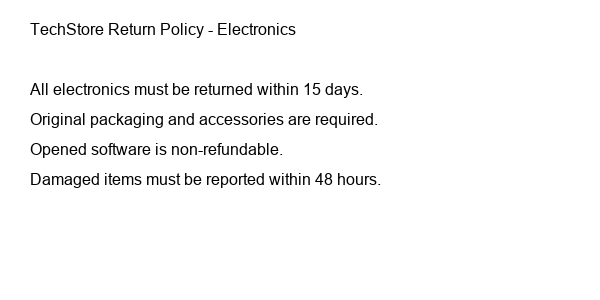

In [65]:
# ═══ Simulate a scanned document ═══
from PIL import Image, ImageDraw, ImageFont

img = Image.new("RGB", (600, 300), color="white")
draw = ImageDraw.Draw(img)

try:
    font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 16)
except Exception:
    try:
        font = ImageFont.truetype("/Library/Fonts/Arial.ttf", 16)
    except Exception:
        font = ImageFont.load_default()

text_lines = [
    "TechStore Return Policy - Electronics",
    "",
    "All electronics must be returned within 15 days.",
    "Original packaging and accessories are required.",
    "Opened software is non-refundable.",
    "Damaged items must be reported within 48 hours.",
]

y = 20
for line in text_lines:
    draw.text((30, y), line, fill="black", font=font)
    y += 30

img.save("sample_docs/scanned_page.png")
print("✅ Created sample_docs/scanned_page.png (simulated scan)")

from IPython.display import display

display(img)


In [66]:
# ═══ OCR with Tesseract ═══
# Requires: brew install tesseract (Mac) or apt-get install tesseract-ocr (Linux)

try:
    import pytesseract
    from PIL import Image

    img = Image.open("sample_docs/scanned_page.png")
    extracted_text = pytesseract.image_to_string(img)

    print("📸 OCR EXTRACTED TEXT:")
    print("─" * 50)
    print(extracted_text)
    print("─" * 50)
    print(f"\n✅ Extracted {len(extracted_text)} characters from image")
    print("   This text can now be chunked and embedded like any other document.")

except Exception as e:
    print(f"⚠️  Tesseract / OCR issue: {e}")
    print("   Install: brew install tesseract (Mac) or apt-get install tesseract-ocr (Linux)")
    print("   Then: pip install pytesseract")


⚠️  Tesseract / OCR issue: tesseract is not installed or it's not in your PATH. See README file for more information.
   Install: brew install tesseract (Mac) or apt-get install tesseract-ocr (Linux)
   Then: pip install pytesseract


### Vision LLM — Better OCR for Complex Documents

When Tesseract struggles (poor scan quality, handwriting, complex layouts), send the image to GPT-4o. It understands document structure much better than traditional OCR.

**Trade-off:** Much more expensive than Tesseract. Use Tesseract first, upgrade to a vision LLM only for documents where OCR fails.


In [6]:
# ═══ Vision LLM extraction (GPT-4o) ═══
import base64

with open("sample_docs/scanned_page.png", "rb") as f:
    img_b64 = base64.b64encode(f.read()).decode()

response = client.chat.completions.create(
    model="gpt-4o",
    messages=[
        {
            "role": "user",
            "content": [
                {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{img_b64}"}},
                {
                    "type": "text",
                    "text": "Extract ALL text from this document image. Preserve the structure and formatting as closely as possible.",
                },
            ],
        }
    ],
    max_tokens=500,
)

extracted = response.choices[0].message.content
print("🤖 GPT-4o EXTRACTED TEXT:")
print("─" * 50)
print(extracted)
print("─" * 50)
print(f"\nTokens used: {response.usage.total_tokens}")
# Rough list pricing (check OpenAI pricing for current rates)
cost = response.usage.prompt_tokens * 2.50e-6 + response.usage.completion_tokens * 10.0e-6
print(f"Approx. cost: ~${cost:.4f}")
print("\n💡 Often better structure than Tesseract, but much more expensive per page.")


🤖 GPT-4o EXTRACTED TEXT:
──────────────────────────────────────────────────
TechStore Return Policy - Electronics

All electronics must be returned within 15 days.
Original packaging and accessories are required.
Opened software is non-refundable.
Damaged items must be reported within 48 hours.
──────────────────────────────────────────────────

Tokens used: 491
Approx. cost: ~$0.0015

💡 Often better structure than Tesseract, but much more expensive per page.


### Quick Comparison: Which Tool When?

| Document Type | Tool | Cost | Quality |
|---|---|---|---|
| Clean text PDF | PyPDF2 or pdfplumber | Free | Good |
| PDF with tables | pdfplumber (extract tables separately) | Free | Good |
| Scanned PDF (clean scan) | Tesseract OCR | Free | Medium |
| Scanned PDF (poor quality / handwriting) | GPT-4o vision | ~$0.01/page | High |
| Images with text | Tesseract or GPT-4o | Free / ~$0.01 | Medium / High |

**The rule:** Start with the cheapest tool. If the output quality is bad, move up. Most documents work fine with pdfplumber + Tesseract. Reserve GPT-4o vision for the hard cases.


### Putting It All Together — Adding Complex Docs to the RAG Pipeline

The extraction method doesn't change the rest of the pipeline. Once you have clean text — whether from `open().read()`, pdfplumber, OCR, or GPT-4o vision — the next steps are identical:

1. Extract text (this chapter)
2. Chunk with RecursiveCharacterTextSplitter (Chapter 5)
3. Embed with OpenAI (Chapter 6)
4. Store in ChromaDB (Chapter 8)
5. Search and generate (Chapters 9–10)

The only difference is step 1. Everything after is the same pipeline.


In [9]:
# ═══ Full pipeline: PDF → chunks → embeddings → ChromaDB → search ═══
from langchain.text_splitter import RecursiveCharacterTextSplitter

# Step 1: Extract text from PDF (pdfplumber)
with pdfplumber.open("sample_docs/sample_report.pdf") as pdf:
    pdf_text = ""
    table_texts = []
    for page in pdf.pages:
        page_text = page.extract_text() or ""
        pdf_text += page_text + "\n\n"
        for table in page.extract_tables() or []:
            headers = table[0]
            for row in table[1:]:
                entry = ", ".join(f"{h}: {v}" for h, v in zip(headers, row) if v)
                table_texts.append(entry)

print(f"Extracted {len(pdf_text)} chars of body text + {len(table_texts)} table rows\n")

# Step 2: Chunk body text; table rows are already short "facts"
splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50,
    separators=["\n\n", "\n", ". ", " ", ""],
)
text_chunks = splitter.split_text(pdf_text)
all_pdf_chunks = text_chunks + table_texts

print(
    f"Chunks: {len(text_chunks)} from text + {len(table_texts)} from tables = {len(all_pdf_chunks)} total\n"
)

# Step 3: Embed
pdf_embeddings = get_embeddings(all_pdf_chunks)

# Step 4: New collection for this demo
try:
    chroma_client.delete_collection("pdf_demo")
except Exception:
    pass

pdf_collection = chroma_client.create_collection(
    name="pdf_demo",
    metadata={"hnsw:space": "cosine"},
)
pdf_collection.add(
    ids=[f"pdf_chunk_{i}" for i in range(len(all_pdf_chunks))],
    embeddings=pdf_embeddings,
    documents=all_pdf_chunks,
    metadatas=[
        {
            "source": "sample_report.pdf",
            "type": "table_row" if i >= len(text_chunks) else "text",
        }
        for i in range(len(all_pdf_chunks))
    ],
)

print(f"✅ Stored {pdf_collection.count()} chunks in ChromaDB\n")

# Step 5: Search
test_questions = [
    "What was the total revenue in Q1 2025?",
    "How many units of ProMax 15 were sold?",
    "Which product had the highest growth?",
]

for q in test_questions:
    q_emb = get_embeddings([q])[0]
    results = pdf_collection.query(
        query_embeddings=[q_emb],
        n_results=2,
        include=["documents", "metadatas", "distances"],
    )

    print(f"Q: {q}")
    for i in range(len(results["documents"][0])):
        score = 1 - results["distances"][0][i]
        doc_type = results["metadatas"][0][i]["type"]
        print(f'  [{score:.3f}] ({doc_type}) "{results["documents"][0][i][:100]}..."')
    print()

print("💡 Table rows (converted to sentences) are retrieved just like text chunks.")
print("   The LLM can now answer 'ProMax 15 revenue?' from the table data.")


Extracted 477 chars of body text + 4 table rows

Chunks: 1 from text + 4 from tables = 5 total

✅ Stored 5 chunks in ChromaDB

Q: What was the total revenue in Q1 2025?
  [0.562] (text) "TechStore Q1 2025 Sales Report
Total revenue for Q1 2025 was $4.2 million, representing a 15% increa..."
  [0.444] (table_row) "Product: ProMax 15, Units Sold: 1,240, Revenue: $1,611,600, Growth: +32%..."

Q: How many units of ProMax 15 were sold?
  [0.783] (table_row) "Product: ProMax 15, Units Sold: 1,240, Revenue: $1,611,600, Growth: +32%..."
  [0.522] (text) "TechStore Q1 2025 Sales Report
Total revenue for Q1 2025 was $4.2 million, representing a 15% increa..."

Q: Which product had the highest growth?
  [0.533] (table_row) "Product: ProMax 15, Units Sold: 1,240, Revenue: $1,611,600, Growth: +32%..."
  [0.512] (text) "TechStore Q1 2025 Sales Report
Total revenue for Q1 2025 was $4.2 million, representing a 15% increa..."

💡 Table rows (converted to sentences) are retrieved just like text chunks.
 